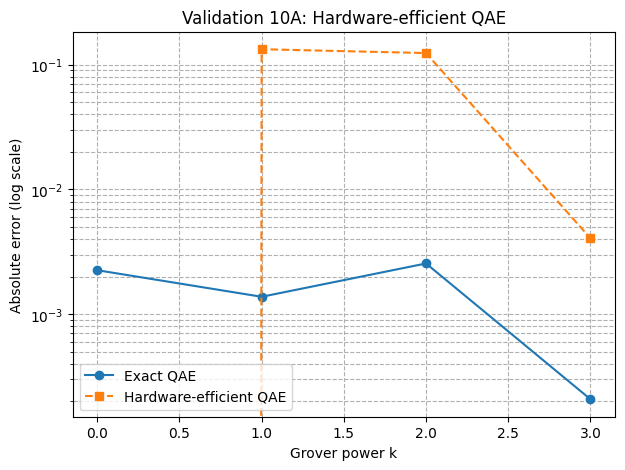

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer.primitives import Sampler

sampler = Sampler()

# -------------------------
# Exact A and Q
# -------------------------
def build_exact_A(p_true):
    theta = 2 * math.asin(math.sqrt(p_true))
    qc = QuantumCircuit(1)
    qc.ry(theta, 0)
    return qc

def build_exact_Q(p_true):
    theta = 2 * math.asin(math.sqrt(p_true))
    qc = QuantumCircuit(1)
    qc.ry(theta, 0)
    qc.z(0)
    qc.ry(-theta, 0)
    qc.x(0); qc.z(0); qc.x(0)
    return qc

# -------------------------
# Hardware-efficient approximations
# -------------------------
def build_HE_A(p_true):
    theta = 2 * math.asin(math.sqrt(p_true))
    approx = round(theta, 2)   # only 2 decimals = coarse hardware precision
    qc = QuantumCircuit(1)
    qc.ry(approx, 0)
    return qc

def build_HE_Q(p_true):
    qc = QuantumCircuit(1)
    # Approximate Grover iteration with fewer rotations
    qc.z(0)
    qc.x(0)
    qc.z(0)
    qc.x(0)
    return qc

# -------------------------
# QAE runner
# -------------------------
def qae_generic(A, Q, p_true, k, shots):
    qc = QuantumCircuit(1,1)
    qc.compose(A, inplace=True)
    for _ in range(k):
        qc.compose(Q, inplace=True)
    qc.measure(0,0)
    dist = sampler.run([qc], shots=shots).result().quasi_dists[0]
    p_k = dist.get(1,0)

    # inversion
    if k == 0: return p_k
    alpha = math.asin(math.sqrt(max(0,min(1,p_k))))
    theta1 = alpha/(2*k+1)
    theta2 = (math.pi - alpha)/(2*k+1)
    p1, p2 = math.sin(theta1)**2, math.sin(theta2)**2
    return p1 if abs(p1-p_true) < abs(p2-p_true) else p2

# -------------------------
# Run comparison
# -------------------------

p_true = 0.15
ks = [0,1,2,3]
shots = 4000

err_exact = []
err_HE = []

for k in ks:
    p_hat_exact = qae_generic(build_exact_A(p_true),
                              build_exact_Q(p_true),
                              p_true, k, shots)
    p_hat_HE    = qae_generic(build_HE_A(p_true),
                              build_HE_Q(p_true),
                              p_true, k, shots)

    err_exact.append(abs(p_hat_exact - p_true))
    err_HE.append(abs(p_hat_HE - p_true))

plt.figure(figsize=(7,5))
plt.plot(ks, err_exact, 'o-', label="Exact QAE")
plt.plot(ks, err_HE, 's--', label="Hardware-efficient QAE")
plt.yscale("log")
plt.xlabel("Grover power k")
plt.ylabel("Absolute error (log scale)")
plt.title("Validation 10A: Hardware-efficient QAE")
plt.grid(True, which='both', ls='--')
plt.legend()
plt.show()

#edit plot to see grover value for orange at k=0

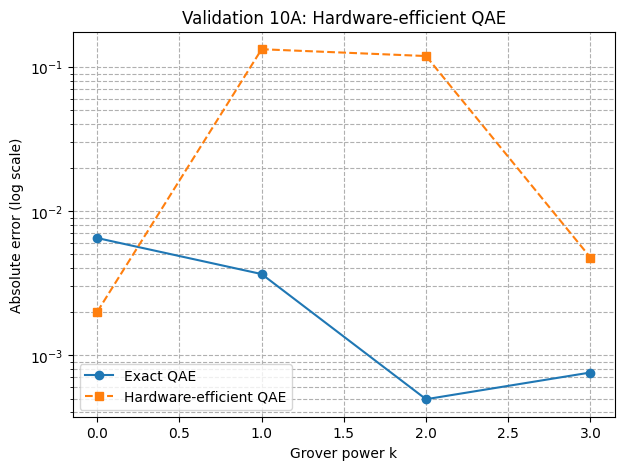

In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer.primitives import Sampler

sampler = Sampler()

# -------------------------
# Exact A and Q
# -------------------------
def build_exact_A(p_true):
    theta = 2 * math.asin(math.sqrt(p_true))
    qc = QuantumCircuit(1)
    qc.ry(theta, 0)
    return qc

def build_exact_Q(p_true):
    theta = 2 * math.asin(math.sqrt(p_true))
    qc = QuantumCircuit(1)
    qc.ry(theta, 0)
    qc.z(0)
    qc.ry(-theta, 0)
    qc.x(0); qc.z(0); qc.x(0)
    return qc

# -------------------------
# Hardware-efficient approximations
# -------------------------
def build_HE_A(p_true):
    theta = 2 * math.asin(math.sqrt(p_true))
    approx = round(theta, 2)   # only 2 decimals = coarse hardware precision
    qc = QuantumCircuit(1)
    qc.ry(approx, 0)
    return qc

def build_HE_Q(p_true):
    qc = QuantumCircuit(1)
    # Approximate Grover iteration with fewer rotations
    qc.z(0)
    qc.x(0)
    qc.z(0)
    qc.x(0)
    return qc

# -------------------------
# QAE runner
# -------------------------
def qae_generic(A, Q, p_true, k, shots):
    qc = QuantumCircuit(1,1)
    qc.compose(A, inplace=True)
    for _ in range(k):
        qc.compose(Q, inplace=True)
    qc.measure(0,0)
    dist = sampler.run([qc], shots=shots).result().quasi_dists[0]
    p_k = dist.get(1,0)

    # inversion
    if k == 0: return p_k
    alpha = math.asin(math.sqrt(max(0,min(1,p_k))))
    theta1 = alpha/(2*k+1)
    theta2 = (math.pi - alpha)/(2*k+1)
    p1, p2 = math.sin(theta1)**2, math.sin(theta2)**2
    return p1 if abs(p1-p_true) < abs(p2-p_true) else p2

# -------------------------
# Run comparison
# -------------------------

p_true = 0.15
ks = [0,1,2,3]
shots = 4000

err_exact = []
err_HE = []

for k in ks:
    p_hat_exact = qae_generic(build_exact_A(p_true),
                              build_exact_Q(p_true),
                              p_true, k, shots)
    p_hat_HE    = qae_generic(build_HE_A(p_true),
                              build_HE_Q(p_true),
                              p_true, k, shots)

    err_exact.append(abs(p_hat_exact - p_true))
    err_HE.append(abs(p_hat_HE - p_true))

plt.figure(figsize=(7,5))
plt.plot(ks, err_exact, 'o-', label="Exact QAE")
plt.plot(ks, err_HE, 's--', label="Hardware-efficient QAE")
plt.yscale("log")
plt.xlabel("Grover power k")
plt.ylabel("Absolute error (log scale)")
plt.title("Validation 10A: Hardware-efficient QAE")
plt.grid(True, which='both', ls='--')
plt.legend()
plt.show()


In [5]:
import numpy as np
import math
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer.primitives import Sampler

sampler = Sampler()

# ------------------------
# 1. Simulate GBM terminal prices
# ------------------------

def simulate_GBM(S0, mu, sigma, T, N_paths):
    Z = np.random.normal(0, 1, size=N_paths)
    ST = S0 * np.exp((mu - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    return ST

# ------------------------
# 2. Discretise into buckets
# ------------------------

def discretise(ST, bins=8):
    hist, edges = np.histogram(ST, bins=bins, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    probs = hist / hist.sum()
    return centers, probs

# ------------------------
# 3. Price European call
# ------------------------

def call_payoff(S, K):
    return np.maximum(S - K, 0)

# ------------------------
# Run full pipeline
# ------------------------

S0 = 100
mu = 0.05
sigma = 0.2
T = 1.0
K = 110
N_paths = 50000

ST = simulate_GBM(S0, mu, sigma, T, N_paths)
centers, probs = discretise(ST, bins=8)

true_price = np.sum(call_payoff(centers, K) * probs)
print("True price:", true_price)

# scale amplitude
C = max(call_payoff(centers, K))
p_true = true_price / C

# ------------------------
# QAE estimation
# ------------------------

k = 1
shots_qae = 5000
p_hat, p_k, _ = run_QAE(p_true, k, shots_qae)
qae_price = C * p_hat

# ------------------------
# Monte Carlo reference
# ------------------------

mc_price = call_payoff(ST, K).mean()

print("MC price        :", mc_price)
print("QAE price       :", qae_price)
print("Absolute errors :", abs(mc_price-true_price), abs(qae_price-true_price))


True price: 5.8996566226967655
MC price        : 6.396884299303667
QAE price       : 5.9933692746212115
Absolute errors : 0.4972276766069017 0.093712651924446


In [4]:
import numpy as np
import math
from qiskit import QuantumCircuit
from qiskit_aer.primitives import Sampler

sampler = Sampler()

# ---------- Core QAE components ----------

def build_single_qubit_QAE(p_true):
    theta_prep = 2 * math.asin(math.sqrt(p_true))
    theta_amp  = theta_prep / 2

    A = QuantumCircuit(1)
    A.ry(theta_prep, 0)

    Q = QuantumCircuit(1)
    Q.ry(theta_prep, 0)
    Q.z(0)
    Q.ry(-theta_prep, 0)
    Q.x(0); Q.z(0); Q.x(0)

    return A, Q, theta_amp

def qae_invert_amplitude(p_true, k, p_k):
    if k == 0:
        return p_k

    p_k = max(0, min(1, p_k))
    alpha = math.asin(math.sqrt(p_k))

    theta1 = alpha/(2*k + 1)
    theta2 = (math.pi - alpha)/(2*k + 1)

    p1 = math.sin(theta1)**2
    p2 = math.sin(theta2)**2

    return p1 if abs(p1 - p_true) < abs(p2 - p_true) else p2

def run_QAE(p_true, k, shots=5000):
    A, Q, _ = build_single_qubit_QAE(p_true)

    qc = QuantumCircuit(1,1)
    qc.compose(A, inplace=True)
    for _ in range(k):
        qc.compose(Q, inplace=True)
    qc.measure(0,0)

    dist = sampler.run([qc], shots=shots).result().quasi_dists[0]
    p_k = dist.get(1, 0)

    p_hat = qae_invert_amplitude(p_true, k, p_k)
    return p_hat, p_k, qc
